# Naive DFT vs FFT
Generated using Gemini 2.5 Pro:
* Prompt 1
> Write a Python script that applies a naïve implementation of the discrete Fourier transform to a signal of length N containing a sine curve using Numpy

* Prompt 2
> Update it to show timings for both the naive DFT and the FFT

--- DFT/FFT Performance Comparison ---
Naïve DFT Execution Time: 0.494153 seconds
NumPy FFT Execution Time: 0.054974 seconds
FFT is approximately 8.99 times faster.

Our DFT implementation is close to NumPy's FFT: True


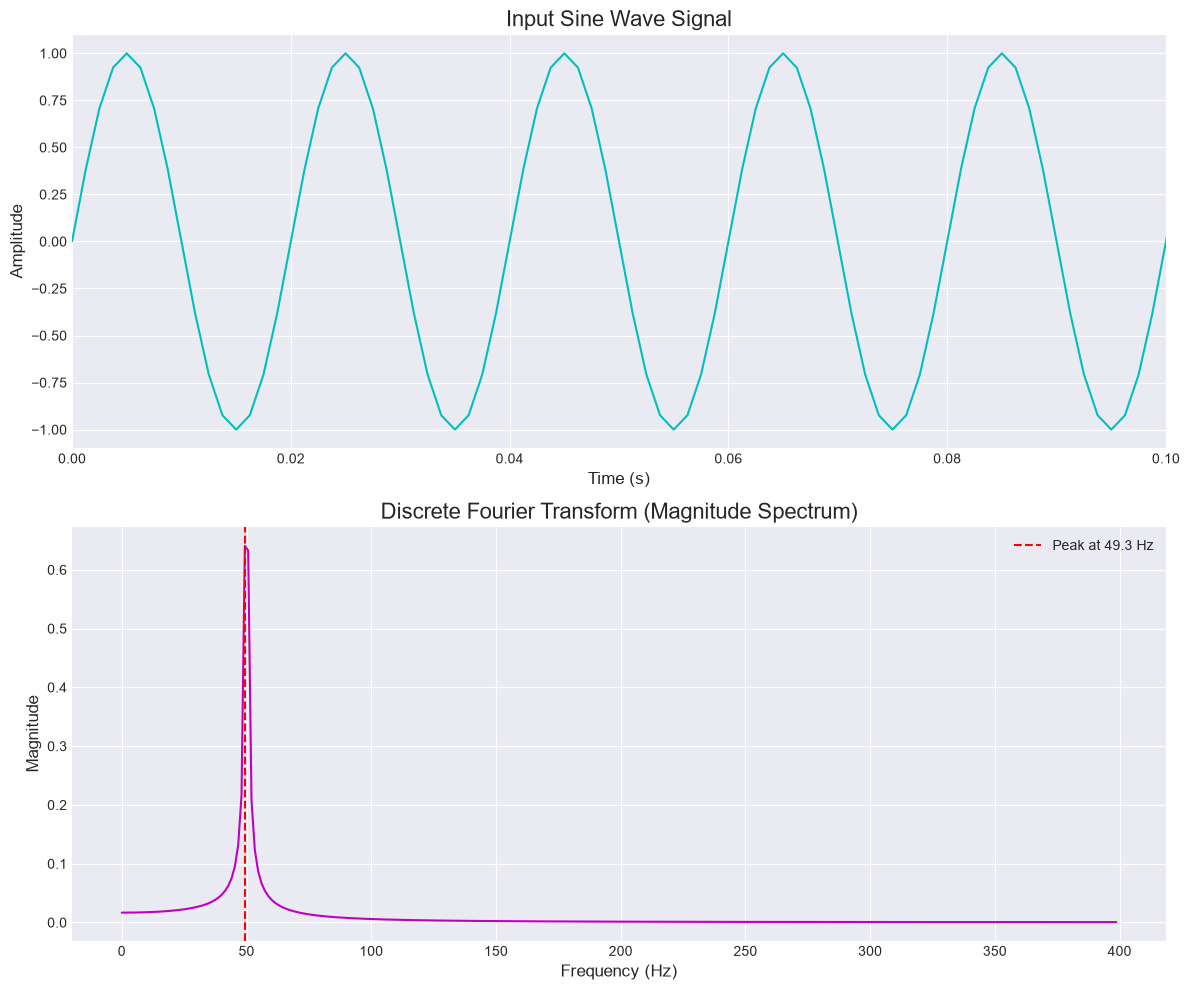

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def naive_dft(x):
    """
    Computes the Discrete Fourier Transform (DFT) of a 1D signal.

    This is a "naïve" implementation that directly follows the DFT formula,
    which has a time complexity of O(N^2).

    Args:
        x (np.ndarray): The input signal, a 1D NumPy array.

    Returns:
        np.ndarray: The complex-valued DFT of the input signal.
    """
    N = len(x)
    # Create an empty array of complex numbers to store the DFT results
    X = np.zeros(N, dtype=np.complex128)

    # Iterate through each frequency bin (k)
    for k in range(N):
        # For each frequency bin, sum the contributions from all input samples (n)
        for n in range(N):
            # The core DFT formula: x[n] * e^(-2j * pi * k * n / N)
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)

    return X

# --- Main Script ---

# 1. Generate the Signal
# Parameters for the signal
N = 600                # Number of sample points
SAMPLE_RATE = 800.0    # Sampling rate in Hz
FREQUENCY = 50.0       # Frequency of the sine wave in Hz

# Calculate sample spacing
T = 1.0 / SAMPLE_RATE

# Create the time vector
# np.linspace generates evenly spaced numbers over a specified interval.
# We use endpoint=False because the interval is periodic.
t = np.linspace(0.0, N * T, N, endpoint=False)

# Create the sine wave signal
y = np.sin(FREQUENCY * 2.0 * np.pi * t)

# 2. Apply the DFT and Time the Execution

# Time the naïve DFT implementation
start_time_naive = time.time()
dft_result = naive_dft(y)
end_time_naive = time.time()
naive_duration = end_time_naive - start_time_naive

# Time NumPy's FFT implementation
start_time_fft = time.time()
fft_result = np.fft.fft(y)
end_time_fft = time.time()
fft_duration = end_time_fft - start_time_fft

# 3. Print Timings and Verification
print("--- DFT/FFT Performance Comparison ---")
print(f"Naïve DFT Execution Time: {naive_duration:.6f} seconds")
print(f"NumPy FFT Execution Time: {fft_duration:.6f} seconds")
# It's possible for the FFT to be so fast that the duration is 0.0, so we handle that case.
if fft_duration > 0:
    print(f"FFT is approximately {naive_duration / fft_duration:.2f} times faster.")
else:
    print("FFT was too fast to measure a significant duration difference.")

# Check if our implementation is close to NumPy's result
# np.allclose is used for comparing floating-point arrays.
print(f"\nOur DFT implementation is close to NumPy's FFT: {np.allclose(dft_result, fft_result)}")


# 4. Prepare for Plotting
# Generate the frequency axis for the plot.
# np.fft.fftfreq returns the DFT sample frequencies.
# We only need the first half of the frequencies (the positive ones) due to symmetry.
xf = np.fft.fftfreq(N, T)[:N//2]

# 5. Visualize the Results
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot the original time-domain signal
ax1.plot(t, y, color='c')
ax1.set_title('Input Sine Wave Signal', fontsize=16)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_xlim(0, 0.1) # Show a few cycles of the sine wave
ax1.grid(True)

# Plot the frequency-domain signal (magnitude of the DFT)
# We normalize the magnitude by N and multiply by 2 to get the correct amplitude.
magnitude = 2.0/N * np.abs(dft_result[0:N//2])
ax2.plot(xf, magnitude, color='m')
ax2.set_title('Discrete Fourier Transform (Magnitude Spectrum)', fontsize=16)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.grid(True)

# Add a vertical line to mark the peak frequency
peak_freq_index = np.argmax(magnitude)
peak_freq = xf[peak_freq_index]
ax2.axvline(peak_freq, color='r', linestyle='--', label=f'Peak at {peak_freq:.1f} Hz')
ax2.legend()


plt.tight_layout()
plt.show()

## Part 2: Applying the DFT/FFT to a Square Wave

The code above runs the naïve DFT and NumPy's FFT on a single sine wave. Here we modify it
to run on a square wave built from a truncated Fourier series (a sum of odd harmonics of a
fundamental frequency).

square_wave_harmonics.ipynb builds square wave from known odd harmonics, this one (naive dft and fft) uses the same wave to get which frequencies are inside it.

We do this to crosscheck that the DFT recovers the same frequencies used to build the wave.

In [ ]:
# --- Modified for Part 2: build a square wave instead of a plain sine wave ---

# Parameters for the square wave
N_sq = 512                  # Number of sample points (kept small: naive DFT is O(N^2))
SAMPLE_RATE_sq = 512.0      # Sampling rate in Hz
T_sq = 1.0 / SAMPLE_RATE_sq # sample spacing
F0_sq = 1.0                 # fundamental frequency of the square wave in Hz
NUM_HARMONICS_sq = 5        # number of odd harmonics used to build the wave (n = 1, 3, 5, 7, 9)

t_sq = np.linspace(0.0, N_sq * T_sq, N_sq, endpoint=False)

# Build the square wave as a truncated Fourier series of odd harmonics
def square_wave_fourier(t, f0, num_harmonics):
    result = np.zeros_like(t)
    for k in range(num_harmonics):
        n = 2 * k + 1  # only odd harmonics contribute to a square wave
        result += np.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result

y_sq = square_wave_fourier(t_sq, F0_sq, NUM_HARMONICS_sq)

# Time the naive DFT implementation (naive_dft is defined in the cell above)
start_time_naive = time.time()
dft_result_sq = naive_dft(y_sq)
naive_duration_sq = time.time() - start_time_naive

# Time NumPy's FFT implementation
start_time_fft = time.time()
fft_result_sq = np.fft.fft(y_sq)
fft_duration_sq = time.time() - start_time_fft

print("--- DFT/FFT Performance Comparison (Square Wave) ---")
print(f"Naïve DFT Execution Time: {naive_duration_sq:.6f} seconds")
print(f"NumPy FFT Execution Time: {fft_duration_sq:.6f} seconds")
if fft_duration_sq > 0:
    print(f"FFT is approximately {naive_duration_sq / fft_duration_sq:.2f} times faster.")
else:
    print("FFT was too fast to measure a significant duration difference.")

print(f"\nOur DFT implementation is close to NumPy's FFT: {np.allclose(dft_result_sq, fft_result_sq)}")
# naive_dft's and FFT's full output are numerically the same thing, so in cell 4, we indirectly also check from FFT

--- DFT/FFT Performance Comparison (Square Wave) ---
Naïve DFT Execution Time: 0.366351 seconds
NumPy FFT Execution Time: 0.000524 seconds
FFT is approximately 699.72 times faster.

Our DFT implementation is close to NumPy's FFT: True


Freq: which Hz is present
Magnitude: how strong, is it meaningfully present, how strong is it relative to the others

In [ ]:
# Compare the frequency components recovered by the DFT with the harmonics used to build the wave
xf_sq = np.fft.fftfreq(N_sq, T_sq)[:N_sq // 2]
magnitude_sq = 2.0 / N_sq * np.abs(dft_result_sq[:N_sq // 2])

expected_harmonics = [2 * k + 1 for k in range(NUM_HARMONICS_sq)]  # n = 1, 3, 5, 7, 9
freq_resolution_sq = SAMPLE_RATE_sq / N_sq  # spacing between DFT frequency bins (Hz)

print(f"{'Harmonic n':>10} | {'Freq (Hz)':>10} | {'Detected mag.':>14} | {'Expected mag. 4/(pi*n)':>22}")
detected_bins = []
for n in expected_harmonics:
    freq = n * F0_sq
    bin_index = int(round(freq / freq_resolution_sq))
    detected_bins.append(bin_index)
    detected_mag = magnitude_sq[bin_index]
    expected_mag = 4.0 / (np.pi * n)
    print(f"{n:>10} | {freq:>10.1f} | {detected_mag:>14.4f} | {expected_mag:>22.4f}")

other_bins_mag = np.delete(magnitude_sq, detected_bins)
print(f"\nAll other frequency bins are ~0 (no extra harmonics present): "
      f"{np.allclose(other_bins_mag, 0, atol=1e-2)}")

Harmonic n |  Freq (Hz) |  Detected mag. | Expected mag. 4/(pi*n)
         1 |        1.0 |         1.2732 |                 1.2732
         3 |        3.0 |         0.4244 |                 0.4244
         5 |        5.0 |         0.2546 |                 0.2546
         7 |        7.0 |         0.1819 |                 0.1819
         9 |        9.0 |         0.1415 |                 0.1415

All other frequency bins are ~0 (no extra harmonics present): True


we also have established that detected = expected (naive_dft's output matches theoretical formula)

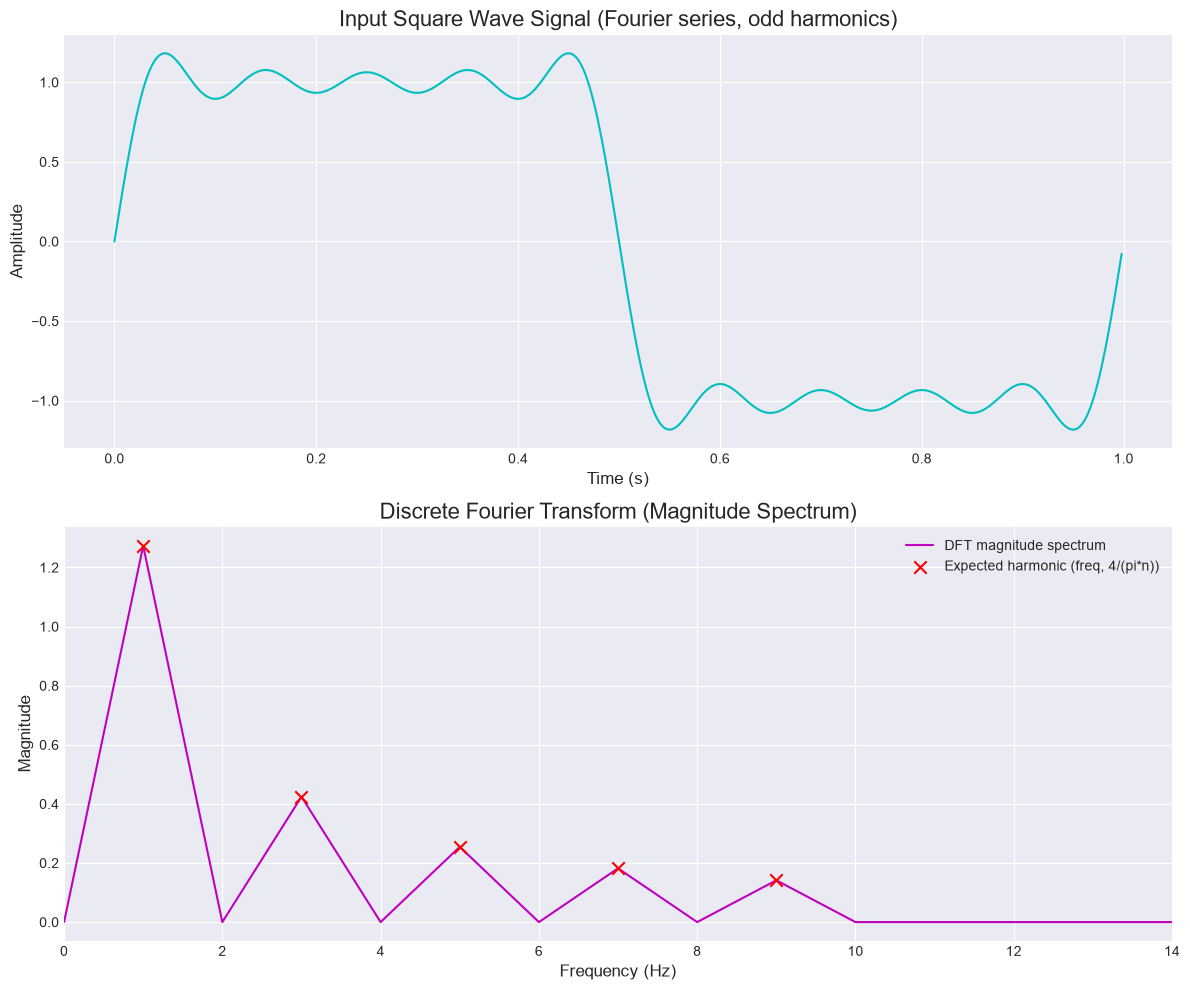

In [4]:
# Visualize the square wave and its recovered spectrum against the expected harmonics
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot the original time-domain signal
ax1.plot(t_sq, y_sq, color='c')
ax1.set_title('Input Square Wave Signal (Fourier series, odd harmonics)', fontsize=16)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.grid(True)

# Plot the frequency-domain signal (magnitude of the DFT) against the expected harmonics
ax2.plot(xf_sq, magnitude_sq, color='m', label='DFT magnitude spectrum')
ax2.scatter([n * F0_sq for n in expected_harmonics],
            [4.0 / (np.pi * n) for n in expected_harmonics],
            color='r', marker='x', s=80, zorder=5, label='Expected harmonic (freq, 4/(pi*n))')
ax2.set_title('Discrete Fourier Transform (Magnitude Spectrum)', fontsize=16)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_xlim(0, expected_harmonics[-1] * F0_sq + 5)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

- Unlike the single-peak spectrum of the sine wave in Part 1, the square wave's spectrum shows peaks exactly at f0, 3f0, 5f0, 7f0, 9f0 - i.e. only the odd harmonics summed in `square_wave_fourier` - with no energy at even harmonics or anywhere else.
- The detected magnitude at each peak matches the theoretical Fourier coefficient 4/(pi\*n) used to build that harmonic, confirming the DFT correctly recovers the components the square wave was constructed from.
- The naive O(N^2) DFT and NumPy's FFT still agree (`np.allclose` is `True`), and the FFT remains dramatically faster, same as in Part 1.
- Try increasing `NUM_HARMONICS_sq` to see more peaks appear in the spectrum, each shrinking in amplitude as 1/n - keep `N_sq` reasonably small if re-running the naive DFT, since it scales as O(N^2).